# Loading and Preprocessing
Preprocessing Techniques & Impact

Text preprocessing transforms raw, noisy text into clean, standardized inputs suitable for numerical feature extraction and machine learning algorithms:

Lowercasing: Converts all characters to lowercase so that words like "Happy", "HAPPY", and "happy" are mapped to the exact same token.

Noise & Special Character Removal: Uses regular expressions to remove URLs, HTML tags, punctuation, and digits. Special symbols add sparsity to the vocabulary without carrying meaningful emotional signal.

Tokenization: Breaks continuous text strings into individual word units (tokens) for isolated feature representation.

Stopword Removal: Eliminates high-frequency grammatical words (e.g., and, the, is) that occur across all emotion categories and carry minimal discriminative sentiment value.

Impact on Model Performance:

Reduces vocabulary dimensionality, drastically speeding up training times and lowering memory consumption.

Eliminates feature noise and prevents models from overfitting to rare symbols or capitalization patterns.

Improves model generalization across unseen text samples.

In [1]:
import re  # text cleaning using regular expression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

In [2]:
# Download NLTK data dependencies
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
from google.colab import drive
import pandas as pd

#Mount Google Drive
drive.mount('/content/drive')

#Load CSV file using its path in google drive
file_path = '/content/drive/MyDrive/nlp_dataset.csv'
df = pd.read_csv(file_path)

Mounted at /content/drive


In [4]:
# Inspect dataset structure
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (5937, 2)

First 5 rows:
                                             Comment Emotion
0  i seriously hate one subject to death but now ...    fear
1                 im so full of life i feel appalled   anger
2  i sit here to write i start to dig out my feel...    fear
3  ive been really angry with r and i feel like a...     joy
4  i feel suspicious if there is no one outside l...    fear


In [6]:
# Identify the label column, based on previous identification it is 'Emotion'
label_col = 'emotion' if 'emotion' in df.columns else df.columns[1]

print("Emotion Counts:")
print(df[label_col].value_counts())

Emotion Counts:
Emotion
anger    2000
joy      2000
fear     1937
Name: count, dtype: int64


In [7]:
# Identify columns (Adjust column names if your CSV uses different names, e.g., 'text' and 'emotion')
text_col = 'text' if 'text' in df.columns else df.columns[0]
label_col = 'emotion' if 'emotion' in df.columns else df.columns[1]
print(f"\n Using '{text_col}' for text and '{label_col}' for target labels.")


 Using 'Comment' for text and 'Emotion' for target labels.


In [8]:
# Check for missing values and drop them
df = df.dropna(subset=[text_col, label_col])

# Set of English stopwords
stop_words = set(stopwords.words('english'))

# Define text cleaning function
def clean_text(text):
    # Ensure input is string
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove punctuation and special characters/numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize
    tokens = text.split()

    # Remove stopwords
    cleaned_tokens = [word for word in tokens if word not in stop_words]

    # Rejoin tokens into a cleaned text string
    return ' '.join(cleaned_tokens)

In [9]:
# Apply preprocessing to dataset
df['cleaned_text'] = df[text_col].apply(clean_text)

# Display sample before and after cleaning
print("\nSample Preprocessing Output:")
for idx, row in df[[text_col, 'cleaned_text']].head(3).iterrows():
    print(f"Original: {row[text_col]}")
    print(f"Cleaned : {row['cleaned_text']}\n")


Sample Preprocessing Output:
Original: i seriously hate one subject to death but now i feel reluctant to drop it
Cleaned : seriously hate one subject death feel reluctant drop

Original: im so full of life i feel appalled
Cleaned : im full life feel appalled

Original: i sit here to write i start to dig out my feelings and i think that i am afraid to accept the possibility that he might not make it
Cleaned : sit write start dig feelings think afraid accept possibility might make



# Feature Extraction
Machine learning algorithms operate on numerical vectors, not raw strings. TfidfVectorizer (Term Frequency-Inverse Document Frequency) converts text into a sparse numerical matrix by calculating two scores for every token $t$ in a document $d$ within a corpus

1)Term Frequency :Measures how frequently a word appears in a specific document.

2)Inverse Document Frequency:Penalizez words that appear frequently across all documents,highlighting unique,highly informative emotion words

3)TF-IDF Weight

This transformation yields a high dimensional feature vector per document where important emotional keywords receive higher weightings while common non-informative words are down weighted.

In [10]:
#Train -Test Split &Feature Extraction (TF-IDF)
X = df['cleaned_text']
y = df[label_col]

# Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Initialize TF-IDF Vectorizer with unigrams and bigrams
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit vectorizer on training set and transform both train and test sets
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Training feature matrix shape: {X_train_tfidf.shape}")
print(f"Testing feature matrix shape : {X_test_tfidf.shape}")

Training feature matrix shape: (4749, 5000)
Testing feature matrix shape : (1188, 5000)


# Model Development

We train two complementary classification models:

Naive Bayes (MultinomialNB): A probabilistic classifier based on Bayes' Theorem.

Support Vector Machine (LinearSVC): A margin-maximization hyperplane classifier well-suited for high-dimensional text matrices.

In [11]:
#Model Training

# Multinomial Naive Bayes Model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

# Support Vector Machine (Linear SVC) Model
svm_model = LinearSVC(random_state=42, C=1.0)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

print("Both Naive Bayes and Support Vector Machine models have been successfully trained.")

Both Naive Bayes and Support Vector Machine models have been successfully trained.


# Model Comparison and Evaluation

In [12]:
# Calculate performance metrics
nb_acc = accuracy_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb, average='weighted')

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')

In [13]:
# Create comparison table
results_df = pd.DataFrame({
    'Model': ['Multinomial Naive Bayes', 'Support Vector Machine (LinearSVC)'],
    'Accuracy': [nb_acc, svm_acc],
    'Weighted F1-Score': [nb_f1, svm_f1]
})

print("=== Performance Comparison Summary ===")
print(results_df.to_string(index=False))

print("\n=== Detailed Classification Report: Naive Bayes ===")
print(classification_report(y_test, y_pred_nb))

print("\n=== Detailed Classification Report: Support Vector Machine ===")
print(classification_report(y_test, y_pred_svm))

=== Performance Comparison Summary ===
                             Model  Accuracy  Weighted F1-Score
           Multinomial Naive Bayes  0.911616           0.911609
Support Vector Machine (LinearSVC)  0.946128           0.946102

=== Detailed Classification Report: Naive Bayes ===
              precision    recall  f1-score   support

       anger       0.91      0.91      0.91       400
        fear       0.91      0.92      0.91       388
         joy       0.92      0.91      0.91       400

    accuracy                           0.91      1188
   macro avg       0.91      0.91      0.91      1188
weighted avg       0.91      0.91      0.91      1188


=== Detailed Classification Report: Support Vector Machine ===
              precision    recall  f1-score   support

       anger       0.94      0.94      0.94       400
        fear       0.94      0.94      0.94       388
         joy       0.95      0.96      0.96       400

    accuracy                           0.95      1188

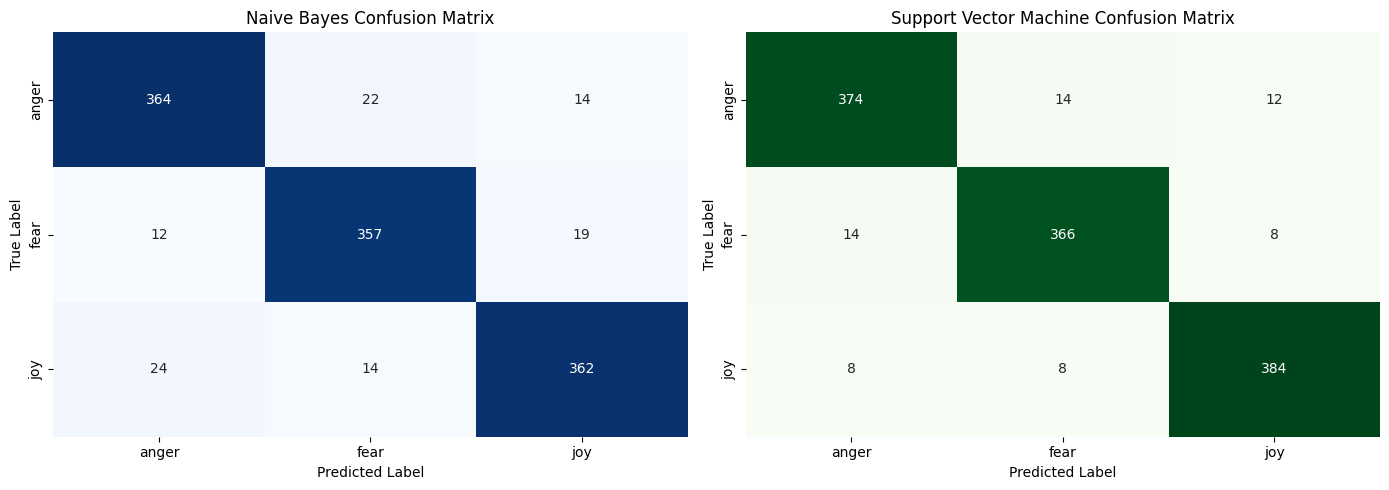

In [27]:
# Get unique labels sorted for matrix plotting
labels = np.unique(y_test)

# Confusion Matrix

labels = np.unique(y_test)
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=labels)
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=labels)

# Combined plot in a single figure context
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Naive Bayes Plot
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=axes[0],
    xticklabels=labels,
    yticklabels=labels
)
axes[0].set_title('Naive Bayes Confusion Matrix', fontsize=12)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Support Vector Machine Plot
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=False,
    ax=axes[1],
    xticklabels=labels,
    yticklabels=labels
)
axes[1].set_title('Support Vector Machine Confusion Matrix', fontsize=12)
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()


Conclusion :
We successfully built and evaluated an end-to-end Machine Learning pipeline to classify text samples into emotion categories (`anger`, `fear`, and `joy`).